# <span style="color:blue">EVAC Workshop 4A: Genetic Programming</span>

**Module leader**

Simon O'Keefe: simon.okeefe@york.ac.uk

**Graduate Teaching Assistants**

Babar Khan: bk777@york.ac.uk

Tianda Sun: tianda.sun@york.ac.uk

## <span style="color:#0073e6">Prerequisites</span>

Before participating in this practical make sure that you have watched the pre-workshop materials:
- Lecture 4
- Code walkthrough 4

# Colab Packages Install

## Learning Objectives

- Learn how to program a standard GP in DEAP
- Learn what kinds of problems GP can be applied to
- Learn the basics of loosely-typed GP in DEAP

# <span style="color:blue">Exercise: Symbolic Regression with GP</span>

To learn genetic programming (GP) we will continue the regression theme and look at a regression problem that needs non-linear expressions. Symbolic regression is about learning equations. Whereas with a GA you need to specify what you think the best model is (e.g. polynomials etc.), with GP the algorithm can decide. This is useful when dealing with more complex data. Here, the data is simply generated by a known function against which we can evaluate.

# <span style="color:blue">Task 1</span>

Using what you know from the lecture and walkthrough: **Your task is to code a GP algorithm to solve a regression problem where the solution is the equation:**

$f(x)$ = $x^{4}$ - $x^{3}$ - $x^{2}$ - $x$

Once you have written your evaluation function, you can then set up a toolbox and register your evaluation function. When you do this, you can specify the range of values over which to assess the individual. Your fitness function should aim to evaluate the error between the individual’s expression and this actual data-generating function.

The code below would register our evaluation function 'evalSymbReg' and pass in argument 'points' which contains values from -10 to 10 every 0.1. Thus we register the range of values of x on which we want to evaluate.

In [133]:
from deap import algorithms, base, creator, tools, gp
import seaborn
import pygraphviz as pgv
import matplotlib.pyplot as plt
import math, operator, random, numpy
from IPython.display import Image

In [134]:
def protectedDiv(num, denom):
    try:
        return num /denom
    except ZeroDivisionError :
        return 1

In [135]:
pset = gp.PrimitiveSet("MAIN", 1)
pset.renameArguments(ARG0='x')
pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)
pset.addPrimitive(protectedDiv, 2)
pset.addPrimitive(operator.neg, 1)
pset.addPrimitive(math.sin, 1)
pset.addPrimitive(math.cos, 1)
pset.addEphemeralConstant("rand101", lambda: random.randint(-1,1))

In [136]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

def evalSymbReg(individual, points):
    func = toolbox.compile(expr=individual)
    sqerrors = ((func(x) - (x**4 - x**3 - x**2 - x))**2 for x in points)
    return math.fsum(sqerrors),

toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=2)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("compile", gp.compile, pset=pset)
toolbox.register("evaluate", evalSymbReg, points=[x/10. for x in range(-100,100)])
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genHalfAndHalf, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=6))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=6))

In [137]:
stats_fit = tools.Statistics(lambda ind: ind.fitness.values)
stats_size = tools.Statistics(len)
mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
mstats.register("avg", numpy.mean)
mstats.register("std", numpy.std)
mstats.register("min", numpy.min)
mstats.register("max", numpy.max)

In [138]:
pop = toolbox.population(n=50)
hof = tools.HallOfFame(1)

pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.1, ngen=100, stats=mstats,
                                   halloffame=hof, verbose=True)

   	      	                                  fitness                                  	                      size                     
   	      	---------------------------------------------------------------------------	-----------------------------------------------
gen	nevals	avg        	gen	max        	min        	nevals	std        	avg 	gen	max	min	nevals	std    
0  	50    	2.21525e+09	0  	2.27416e+09	2.16001e+09	50    	1.40298e+07	3.82	0  	7  	2  	50    	1.35189
1  	26    	2.21141e+09	1  	2.21799e+09	2.16001e+09	26    	1.51679e+07	4.1 	1  	7  	2  	26    	1.40357
2  	31    	2.21153e+09	2  	2.27314e+09	2.16001e+09	31    	2.20772e+07	4   	2  	9  	2  	31    	1.49666
3  	25    	2.2058e+09 	3  	2.2183e+09 	2.16001e+09	25    	2.14615e+07	3.62	3  	7  	2  	25    	1.19817
4  	30    	2.20451e+09	4  	2.21729e+09	2.15901e+09	30    	2.23104e+07	3.94	4  	8  	1  	30    	1.50213
5  	26    	2.19434e+09	5  	2.2165e+09 	2.15901e+09	26    	2.69575e+07	3.94	5  	7  	2  	26    	1.39155
6  	27    	2.188

Note that in the walkthrough I showed you how to fit a function to data we already have, but in this case we have a function and can  generate the input data for the on-the-fly using the data-generating function that is shown above.

We pass the individual to the evaluation function, just as we have always done previously. But we also pass the inputs that we want to evaluate.

I chose to pass in a big range of points that are systematically generated, but you can change that function to be anything you want (see later task), and even add randomness to it.

# <span style="color:blue">Task 2</span>

Once you have implemented a solution, you can output statistics, plot trees, and take a look at the final solution.

To see the effect of different parameter choices on the solution, now run your algorithm with different mutation rates. Use a small, fixed number of generations and look at the effect of the mutation rate on the best individual found for each mutation rate.

Remember to run your code multiple times for each value of the mutation rate to account for the impact of random starting conditions on the best solution found.

Use a statistical test to determine whether there is a stastically significant difference between the outcomes.

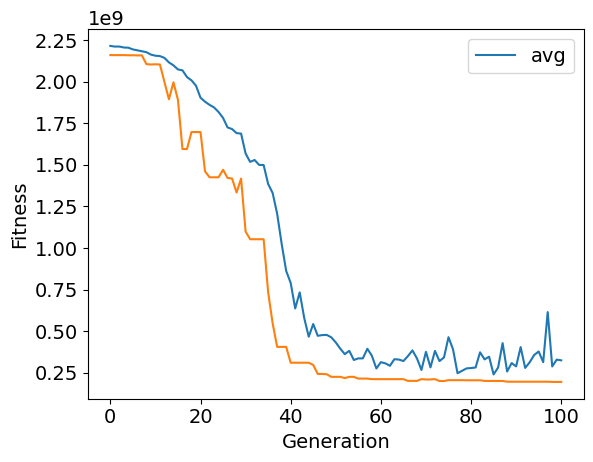

In [ ]:
%matplotlib inline
gen = log.chapters['fitness'].select("gen")
_min = log.chapters['fitness'].select("min")
_max = log.chapters['fitness'].select("max")
avgs = log.chapters['fitness'].select("avg")
stds = log.chapters['fitness'].select("std")

plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)

fig, ax1 = plt.subplots()
line1 = ax1.plot(gen, avgs, label='avg')
ax1.set_xlabel("Generation")
ax1.set_ylabel("Fitness")
line2 = ax1.plot(gen, _min, label='min')
# line3 = ax1.plot(gen, _max, label='max')

ax1.legend()

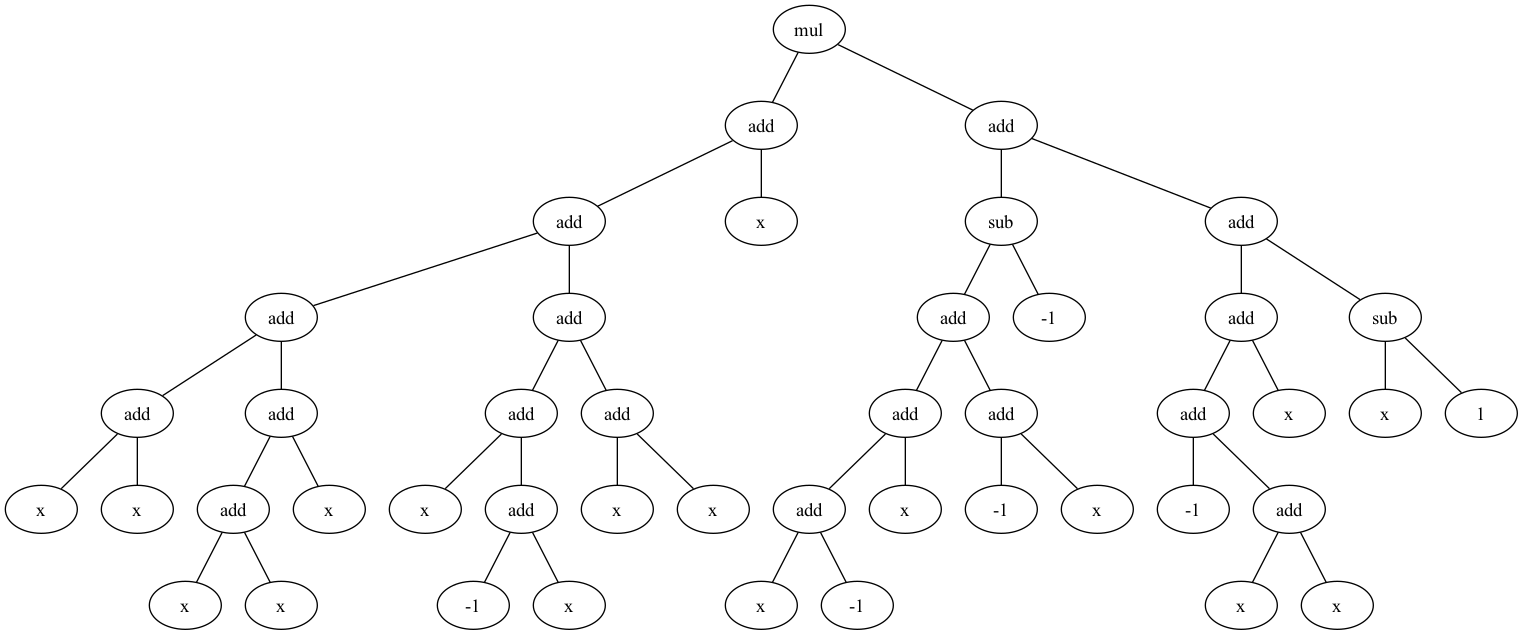

In [143]:
indv = tools.selBest(pop, 1)[0]
nodes, edges, labels = gp.graph(indv)

tree = pgv.AGraph()
tree.add_nodes_from(nodes)
tree.add_edges_from(edges)
tree.layout(prog="dot")

for i in nodes:
    n = tree.get_node(i)
    n.attr["label"] = labels[i]

treeplot = tree.draw(format='png', prog='dot')
Image(treeplot)

# <span style="color:blue">Additional Task 1</span>

Start with a more complex primitive set and experiment with changes to it. How much can you slim it down, and what impact does it have?

You will notice that the final solution performs well but is not very concise. This is common in GP and is called 'bloating'. Why do you think bloating happens? This is a topic covered in the next lecture and workshop.

# <span style="color:blue">Additional Task 2</span>

Add a static depth limit to your mutation and mating operators. Set the limit to 8. Remember that this limit is a limit on the overall depth of an individual. Re-run and look at the final tree.

# <span style="color:blue">Additional Task 3</span>

Let's change your evaluation function to something more difficult. For example, you could use something from the DEAP benchmarks such as deap.benchmarks.gp.ripple (see library reference). The ripple function takes in two arguments and is defined as:

$f(x)$ = ($x_{1} - 3$)($x_{2} - 3$) + 2sin(($x_{1} - 4$)($x_2 - 4$))

With range x $∈[-5,5$]^2

# <span style="color:blue">Additional Task 4</span>

You can actually implement multiple types of mutation functions in GP. Because of the tree structure, there are many different ways that you can change individuals.

Go to the DEAP library reference and read about the different gp mutation operators such as gp.mutShrink(), gp.mutNodeReplacement(), go.mutInsert(), and gp.mutEphemeral().

Implement gp.mutShrink() in to you code in addition to the current mutation operator.